In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
exp_density = {280: 0.99987, 290: 0.99877, 300: 0.99657, 310: 0.99342, 320: 0.98945, 330: 0.98479}

In [3]:
# mace_small_280 = pd.read_csv('output/wat_mace_small/wat_280_npt_density.csv')

temperatures = [280, 290, 300, 310, 320, 330]
final_part_size = 0.5

grace_2l_small = dict()
grace_2l_small_mean = dict()
for temp in temperatures:
    path = f'output/2l_wat_grace_small_b_off/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        grace_2l_small[temp] = pd.read_csv(path)
        grace_2l_small_mean[temp] = grace_2l_small[temp][int(len(grace_2l_small[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        grace_2l_small[temp] = None
        grace_2l_small_mean[temp] = None



grace_2l_medium = dict()
grace_2l_medium_mean = dict()
for temp in temperatures:
    path = f'output/2l_wat_grace_medium_b_off/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        grace_2l_medium[temp] = pd.read_csv(path)
        grace_2l_medium_mean[temp] = grace_2l_medium[temp][int(len(grace_2l_medium[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        grace_2l_medium[temp] = None
        grace_2l_medium_mean[temp] = None


mace_small = dict()
mace_small_mean = dict()
for temp in temperatures:
    path = f'output/wat_mace_small/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        mace_small[temp] = pd.read_csv(path)
        mace_small_mean[temp] = mace_small[temp][int(len(mace_small[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        mace_small[temp] = None
        mace_small_mean[temp] = None

mace_medium = dict()
mace_medium_mean = dict()
for temp in temperatures:
    path = f'output/wat_mace_medium/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        mace_medium[temp] = pd.read_csv(path)
        mace_medium_mean[temp] = mace_medium[temp][int(len(mace_medium[temp])*final_part_size):]['density_g_cm3'].mean()
    else:
        print(f"File not found: {path}")
        mace_medium[temp] = None
        mace_medium_mean[temp] = None

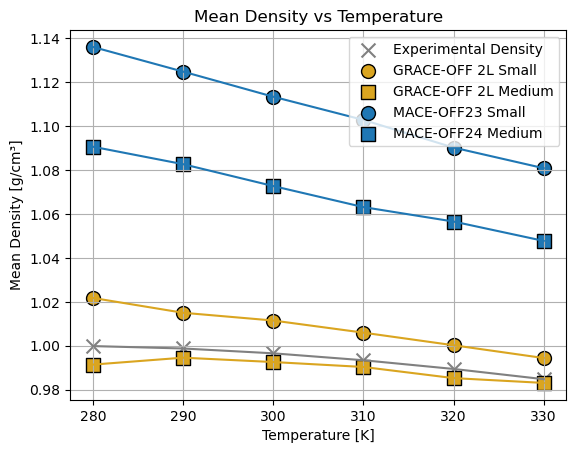

In [4]:
grace_color_small = "goldenrod"       # Gelb für GRACE small
grace_color_medium = "goldenrod"      # Gelb für GRACE medium (selbe Familie, daher gleiche Farbe)

mace_color_small = "tab:blue"    # Blau für MACE small
mace_color_medium = "tab:blue"   # Blau für MACE medium

marker_small = "o"   # alle small-Modelle
marker_medium = "s"  # alle medium-Modelle

# --- Experimental ---
plt.scatter(exp_density.keys(), exp_density.values(),
            color='gray', marker='x', s=100, label='Experimental Density')
plt.plot(exp_density.keys(), exp_density.values(), color='gray')

# --- GRACE small ---
plt.scatter(grace_2l_small_mean.keys(), grace_2l_small_mean.values(),
            color=grace_color_small, marker=marker_small, edgecolor='k', s=100,
            label='GRACE-OFF 2L Small')
plt.plot(grace_2l_small_mean.keys(), grace_2l_small_mean.values(),
         color=grace_color_small)

# --- GRACE medium ---
plt.scatter(grace_2l_medium_mean.keys(), grace_2l_medium_mean.values(),
            color=grace_color_medium, marker=marker_medium, edgecolor='k', s=100,
            label='GRACE-OFF 2L Medium')
plt.plot(grace_2l_medium_mean.keys(), grace_2l_medium_mean.values(),
         color=grace_color_medium)

# --- MACE small ---
plt.scatter(mace_small_mean.keys(), mace_small_mean.values(),
            color=mace_color_small, marker=marker_small, edgecolor='k', s=100,
            label='MACE-OFF23 Small')
plt.plot(mace_small_mean.keys(), mace_small_mean.values(),
         color=mace_color_small)

# --- MACE medium ---
plt.scatter(mace_medium_mean.keys(), mace_medium_mean.values(),
            color=mace_color_medium, marker=marker_medium, edgecolor='k', s=100,
            label='MACE-OFF24 Medium')
plt.plot(mace_medium_mean.keys(), mace_medium_mean.values(),
         color=mace_color_medium)

plt.xticks([280, 290, 300, 310, 320, 330])
plt.legend()
plt.grid(True)
plt.xlabel('Temperature [K]')
plt.ylabel('Mean Density [g/cm³]')
plt.title('Mean Density vs Temperature')
plt.savefig('density_vs_temperature.png', dpi=300)
plt.show()


In [5]:
def get_data(model_type: str, size: str, temp: int) -> pd.DataFrame:
    path = f'output/{model_type}_wat_grace_{size}_b_off/wat_{temp}_npt_density.csv'
    if os.path.exists(path):
        return pd.read_csv(path)
    else:
        print(f"File not found: {path}")
        return None

grace = get_data('2l', 'medium', 310)
grace

,time_ps,volume_A3,density_g_cm3,ns_per_day
0,0.0,17169.518,0.99660,NaN
1,0.1,17122.236,0.99935,0.25907
2,0.2,16966.652,1.00852,0.38599
3,0.3,16808.938,1.01798,0.46085
4,0.4,16759.809,1.02096,0.51023
...,...,...,...,...
1996,199.6,17357.186,0.98583,0.76558
1997,199.7,17351.813,0.98613,0.76558
1998,199.8,17368.920,0.98516,0.76558
1999,199.9,17364.669,0.98540,0.76559
